In [1]:
# ============================================
# : IMPORT LIBRARIES & LOAD DATASET
# ============================================

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset

df = pd.read_csv(r"C:\Users\Acer\Downloads\Medical_insurance (1).csv")

# Display First 5 Rows

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(2772, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
df.children.unique()

array([0, 1, 3, 2, 5, 4])

In [9]:
df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [10]:
smok_map={'no':0,'yes':1}
df['smoker']=df['smoker'].replace(smok_map)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,0,southeast,8569.86180
2768,21,female,34.600,0,0,southwest,2020.17700
2769,19,male,26.030,1,1,northwest,16450.89470
2770,23,male,18.715,0,0,northwest,21595.38229


In [11]:
df.sex.unique()

array(['female', 'male'], dtype=object)

In [12]:
sex_map={'female':0, 'male':1}
df['sex']=df['sex'].replace(sex_map)
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,0,45.320,1,0,southeast,8569.86180
2768,21,0,34.600,0,0,southwest,2020.17700
2769,19,1,26.030,1,1,northwest,16450.89470
2770,23,1,18.715,0,0,northwest,21595.38229


In [13]:
df.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [14]:
reg_map={'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3}
df['region']=df['region'].replace(reg_map)
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520
...,...,...,...,...,...,...,...
2767,47,0,45.320,1,0,1,8569.86180
2768,21,0,34.600,0,0,0,2020.17700
2769,19,1,26.030,1,1,2,16450.89470
2770,23,1,18.715,0,0,2,21595.38229


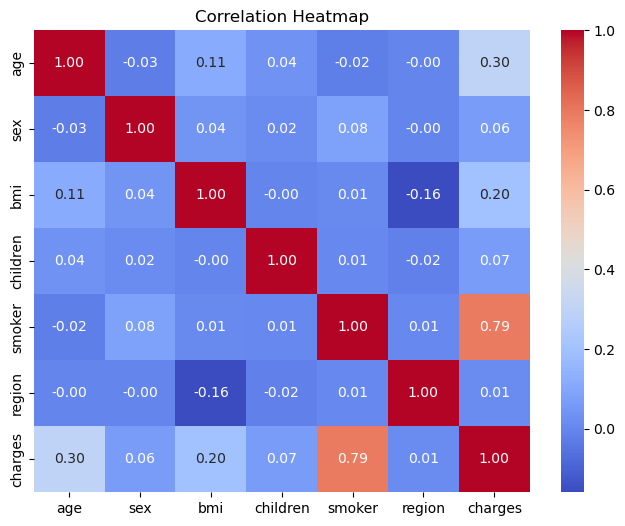

In [15]:
#eda
#correlation heatmap
corr = df.corr()
corr
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

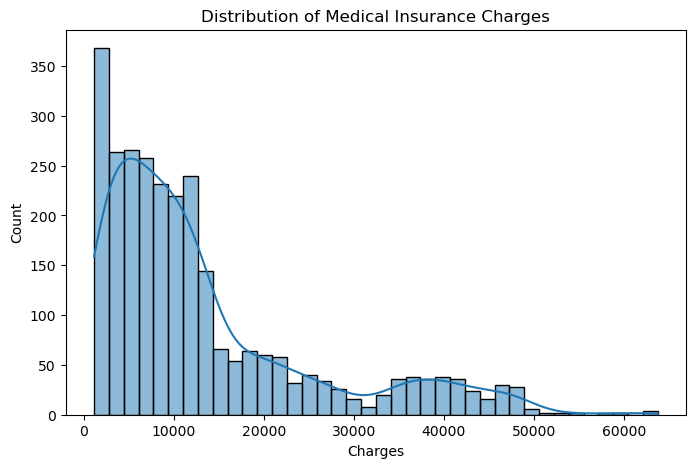

In [16]:
#distribution of target variable
plt.figure(figsize=(8,5))

sns.histplot(df['charges'],
             kde=True)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")

plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# TRAIN-TEST SPLIT & FEATURE SCALING
# Features (Independent Variables)

X = df.drop('charges', axis=1)

# Target Variable (Dependent Variable)

y = df['charges']

# Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Standardize the Features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# train models one by one

In [18]:
# ============================================
# : MODEL BUILDING & EVALUATION
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import pandas as pd

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}
results = []

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append([name, r2, mae, mse, rmse])

    print("="*60)
    print(name)
    print("="*60)
    print("R2 Score :", round(r2,4))
    print("MAE      :", round(mae,2))
    print("MSE      :", round(mse,2))
    print("RMSE     :", round(rmse,2))

    

Linear Regression
R2 Score : 0.7399
MAE      : 4167.3
MSE      : 39922479.35
RMSE     : 6318.42
Decision Tree
R2 Score : 0.9368
MAE      : 683.1
MSE      : 9704817.9
RMSE     : 3115.26
Random Forest
R2 Score : 0.9505
MAE      : 1306.11
MSE      : 7593415.52
RMSE     : 2755.62
Gradient Boosting
R2 Score : 0.8772
MAE      : 2266.65
MSE      : 18843332.95
RMSE     : 4340.89
AdaBoost
R2 Score : 0.8286
MAE      : 3917.78
MSE      : 26299929.31
RMSE     : 5128.35
Support Vector Regressor
R2 Score : -0.0657
MAE      : 8297.13
MSE      : 163569917.51
RMSE     : 12789.45


In [20]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "R2 Score",
    "MAE",
    "MSE",
    "RMSE"
])

results_df

,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.739886,4167.301436,3.992248e+07,6318.423803
1,Decision Tree,0.936769,683.099894,9.704818e+06,3115.255671
2,Random Forest,0.950525,1306.110050,7.593416e+06,2755.615270
3,Gradient Boosting,0.877227,2266.653851,1.884333e+07,4340.890802
4,AdaBoost,0.828644,3917.783011,2.629993e+07,5128.345670
5,Support Vector Regressor,-0.065734,8297.131811,1.635699e+08,12789.445551


In [21]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,R2 Score,MAE,MSE,RMSE
2,Random Forest,0.950525,1306.110050,7.593416e+06,2755.615270
1,Decision Tree,0.936769,683.099894,9.704818e+06,3115.255671
3,Gradient Boosting,0.877227,2266.653851,1.884333e+07,4340.890802
4,AdaBoost,0.828644,3917.783011,2.629993e+07,5128.345670
0,Linear Regression,0.739886,4167.301436,3.992248e+07,6318.423803
5,Support Vector Regressor,-0.065734,8297.131811,1.635699e+08,12789.445551


In [22]:
# to find best model highest r2 ,lowest mae or rmse

In [23]:
best_model = results_df.iloc[0]

print("Best Model")
print(best_model)

Best Model
Model        Random Forest
R2 Score          0.950525
MAE             1306.11005
MSE         7593415.517777
RMSE            2755.61527
Name: 2, dtype: object


In [24]:
print("Best Regression Model :", best_model["Model"])

Best Regression Model : Random Forest


In [25]:
print("Best R2 Score :", best_model["R2 Score"])

Best R2 Score : 0.9505253572984594


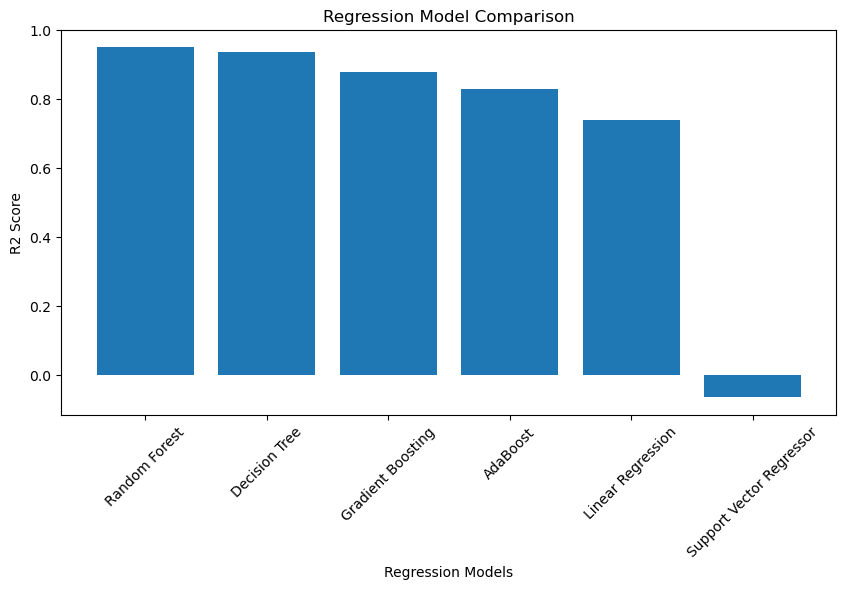

In [26]:
# visualize model comparision (R²Score)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.xticks(rotation=45)

plt.xlabel("Regression Models")

plt.ylabel("R2 Score")

plt.title("Regression Model Comparison")

plt.show()

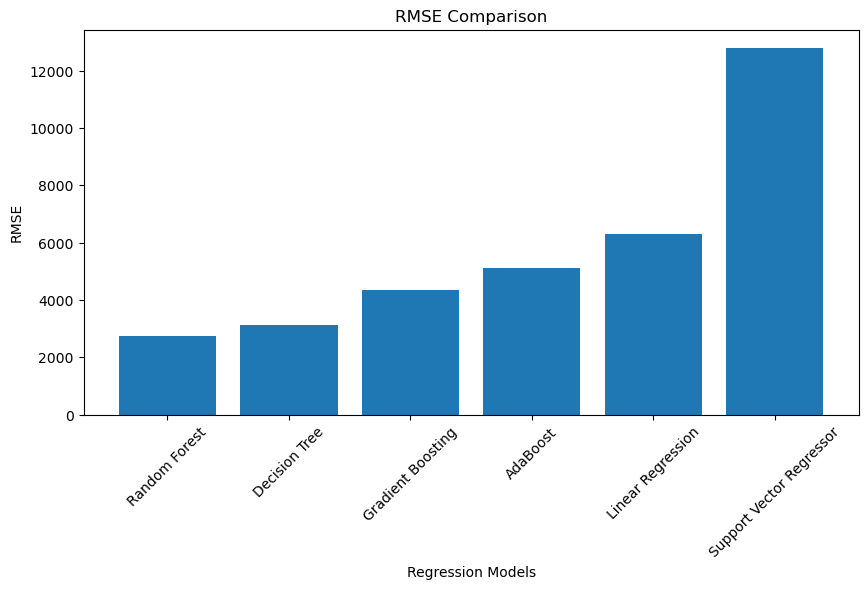

In [27]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.xticks(rotation=45)

plt.xlabel("Regression Models")

plt.ylabel("RMSE")

plt.title("RMSE Comparison")

plt.show()

In [28]:
best_model_name = results_df.iloc[0]["Model"]

print("Selected Best Model :", best_model_name)

Selected Best Model : Random Forest


# hyperparameter tuning

In [29]:
# ============================================
# : HYPERPARAMETER TUNING
# ============================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [30]:
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [31]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [32]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.9159248907974767


In [33]:
best_rf = grid_search.best_estimator_

print(best_rf)

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)


In [34]:
y_pred = best_rf.predict(X_test)

In [35]:
#model evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", round(r2,4))
print("MAE      :", round(mae,2))
print("MSE      :", round(mse,2))
print("RMSE     :", round(rmse,2))

R2 Score : 0.9506
MAE      : 1310.09
MSE      : 7577509.9
RMSE     : 2752.73


In [36]:
print("="*50)
print("Best Model : Random Forest Regressor")
print("="*50)

print("Best Parameters :", grid_search.best_params_)
print("Best Cross Validation Score :", round(grid_search.best_score_,4))
print("Test R2 Score :", round(r2,4))
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE :", round(rmse,2))

Best Model : Random Forest Regressor
Best Parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Score : 0.9159
Test R2 Score : 0.9506
MAE : 1310.09
MSE : 7577509.9
RMSE : 2752.73


# interactive input

In [37]:
print("Enter the following details to predict Medical Insurance Charges:")

age = int(input("Age: "))

print("Sex: female, male")
sex = input("Sex: ").strip()
sex = sex_map.get(sex,0)

bmi = float(input("BMI: "))

children = int(input("Number of Children: "))

print("Smoker: no, yes")
smoker = input("Smoker: ").strip()
smoker = smok_map.get(smoker,0)

print("Region: northeast, northwest, southeast, southwest")
region = input("Region: ").strip()
region = reg_map.get(region,0)

Enter the following details to predict Medical Insurance Charges:


Age:  60


Sex: female, male


Sex:  male
BMI:  28
Number of Children:  3


Smoker: no, yes


Smoker:  yes


Region: northeast, northwest, southeast, southwest


Region:  southeast


In [40]:
user_data =np.array([
    age,
    sex,
    bmi,
    children,
    smoker,
    region
]).reshape(1,-1)
#scale input
user_data_scaled = scaler.transform(user_data)
#predict
prediction = best_rf.predict(user_data_scaled)
print("\n" + "="*50)
print("Predicted Medical  Charges")
print("="*50)

print(f"Estimated  medical Charge: ₹{prediction[0]:,.2f}")


Predicted Medical  Charges
Estimated  medical Charge: ₹28,986.27


In [39]:
import pickle

# Save the scaler
with open('medical_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the model
with open('medical_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
